### Customer churn prediction

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [49]:
df=pd.read_csv("../datasets/customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

In [ ]:
df.info

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [50]:
X= df.drop(columns=["customerID","Churn"])
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [70]:
y=df["Churn"]
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object

In [85]:
# y= pd.get_dummies(y,drop_first=True,dtype=int)
# y.head()

y = df["Churn"].map({"No": 0, "Yes": 1})

In [86]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [87]:
df_encoded = pd.get_dummies(X,drop_first=True,dtype=int)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29.85,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,34,56.95,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,2,53.85,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,45,42.30,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,2,70.70,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clean visuals
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

# Countplot for Churn
sns.countplot(data=df, x="Churn", palette="Set2")
plt.title("Overall Churn Distribution")
plt.xlabel("Churned?")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
categorical_features = ["Contract", "InternetService", "PaymentMethod"]

for col in categorical_features:
    plt.figure(figsize=(10, 5))
    # Grouped countplot showing Churn split for each category
    sns.countplot(data=df, x=col, hue="Churn", palette="Set2")
    plt.title(col + " vs Churn")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=15)  # Rotates text slightly so it doesn't overlap
    plt.legend(title="Churn")
    plt.tight_layout()
    plt.show()

In [ ]:
numerical_features = ["tenure", "MonthlyCharges"]

for col in numerical_features:
    plt.figure(figsize=(10, 4))
    # KDE plot creates a smooth curve showing density
    sns.kdeplot(
        data=df, x=col, hue="Churn", fill=True, common_norm=False, palette="Set2"
    )
    plt.title(col + " Distribution by Churn")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.show()

In [ ]:
df.describe()

In [ ]:
X.isnull().sum()

In [88]:
target_columns = ["gender","SeniorCitizen","Partner","InternetService", "Contract", "PaymentMethod","Dependents","PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaperlessBilling","PaymentMethod"]

df_encoded = pd.get_dummies(X, columns=target_columns,drop_first=True,dtype=int)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [89]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Clean TotalCharges (Note the comma here!)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# 2. Re-create your numerical subset
X1 = df[["tenure", "MonthlyCharges", "TotalCharges"]]

# 3. Drop them from df_encoded first to avoid duplicate columns
df_encoded_clean = df_encoded.drop(
    columns=["tenure", "MonthlyCharges", "TotalCharges"], errors="ignore"
)
final_df = pd.concat([df_encoded_clean, X1], axis=1)

# 4. Scale safely
scaler = StandardScaler()
scale_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
final_df[scale_cols] = scaler.fit_transform(final_df[scale_cols])

final_df.head()

,gender_Male,SeniorCitizen_1,Partner_Yes,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure,MonthlyCharges,TotalCharges
0,0,0,1,0,0,0,0,0,1,0,...,0,0,0,1,0,1,0,-1.277445,-1.160323,-0.992611
1,1,0,0,0,0,1,0,0,0,1,...,0,1,0,0,0,0,1,0.066327,-0.259629,-0.172165
2,1,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,1,-1.236724,-0.362660,-0.958066
3,1,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0.514251,-0.746535,-0.193672
4,0,0,0,1,0,0,0,0,1,0,...,0,0,0,1,0,1,0,-1.236724,0.197365,-0.938874


In [78]:
from sklearn.model_selection import train_test_split

In [90]:
X_train,X_test,y_train,y_test=train_test_split(final_df,y,test_size=0.2,random_state=42,stratify=y)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [91]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")
# Double check that no object types remain  
print(X_train.dtypes.value_counts())

float32    37
Name: count, dtype: int64


In [92]:
print(type(y_train))
print(y_train.shape)
print(y_train.head())

<class 'pandas.core.series.Series'>
(5634,)
3738    0.0
3151    0.0
4860    0.0
3867    0.0
3810    0.0
Name: Churn, dtype: float32


In [93]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Calculate weights based ONLY on your training target (y_train)
weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)

# Convert to the dictionary format Keras expects: {class_index: weight}
class_weights = {0: weights[0], 1: weights[1]}

print("Class Weights for Keras:", class_weights)
# Output will look roughly like: {0: 0.68, 1: 1.88}
# This tells Keras to value a 'Yes' (1) roughly 3x more than a 'No' (0)

Class Weights for Keras: {0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}


In [94]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input,Dense,Dropout
from keras.models import Sequential
from keras.metrics import Recall,Precision,AUC

In [95]:
model=Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1,activation="sigmoid")

])

model.compile(
    optimizer="adam",loss="binary_crossentropy",metrics=["accuracy", Recall(),AUC()]
)

In [113]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,  # Holds out 10% of train data to monitor overfitting
    class_weight=class_weights,  # <-- Tying it all together here!
    verbose=1,
)

Epoch 1/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9507 - auc_10: 0.9931 - loss: 0.0974 - recall_10: 0.9778 - val_accuracy: 0.7145 - val_auc_10: 0.7036 - val_loss: 2.2052 - val_recall_10: 0.5103
Epoch 2/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9473 - auc_10: 0.9939 - loss: 0.0940 - recall_10: 0.9763 - val_accuracy: 0.7181 - val_auc_10: 0.6976 - val_loss: 2.3767 - val_recall_10: 0.4828
Epoch 3/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9464 - auc_10: 0.9940 - loss: 0.0915 - recall_10: 0.9837 - val_accuracy: 0.7234 - val_auc_10: 0.6942 - val_loss: 2.3784 - val_recall_10: 0.4897
Epoch 4/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9485 - auc_10: 0.9938 - loss: 0.0932 - recall_10: 0.9770 - val_accuracy: 0.7004 - val_auc_10: 0.6958 - val_loss: 2.3387 - val_recall_10: 0.5310
Epoch 5/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9434 - auc_10: 0.9931 - loss: 0.0969 - recall_10: 0.9822 - val_accuracy: 0.7074 - val_auc_10: 

In [111]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

In [116]:
# Get predicted probabilities
y_pred_probs = model.predict(X_test).ravel()

# Convert probabilities to binary class predictions (threshold at 0.5)
y_pred = (y_pred_probs > 0.5).astype(int)

# Calculate Classification Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_probs)  # AUC needs probabilities, not hard predictions
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Display Results
print("\n" + "="*35)
print("     FINAL CLASSIFICATION METRICS   epochs=50 no early stopping,dropouts,batchnormalization ")
print("="*35)
print(f"Accuracy  : {accuracy:.4f}")
print(f"AUC Score : {auc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("="*35)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

     FINAL CLASSIFICATION METRICS   epochs=50 no early stopping,dropouts,batchnormalization 
Accuracy  : 0.7424
AUC Score : 0.7780
Precision : 0.5135
Recall    : 0.5588
F1-Score  : 0.5352


In [115]:
history_two = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,  # Holds out 10% of train data to monitor overfitting
    class_weight=class_weights,  # <-- Tying it all together here!
    verbose=1,
)

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9495 - auc_10: 0.9935 - loss: 0.0955 - recall_10: 0.9733 - val_accuracy: 0.7039 - val_auc_10: 0.6886 - val_loss: 2.4832 - val_recall_10: 0.4966
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9507 - auc_10: 0.9946 - loss: 0.0871 - recall_10: 0.9837 - val_accuracy: 0.7074 - val_auc_10: 0.6859 - val_loss: 2.5383 - val_recall_10: 0.4897
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9540 - auc_10: 0.9948 - loss: 0.0857 - recall_10: 0.9815 - val_accuracy: 0.7110 - val_auc_10: 0.6963 - val_loss: 2.4718 - val_recall_10: 0.5034
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9535 - auc_10: 0.9949 - loss: 0.0853 - recall_10: 0.9807 - val_accuracy: 0.7234 - val_auc_10: 0.6865 - val_loss: 2.5917 - val_recall_10: 0.4897
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9519 - auc_10: 0.9944 - loss: 0.0875 - recall_10: 0.9756 - val_accuracy: 0.7216 - val_auc

In [117]:
# Get predicted probabilities
y_pred_probs = model.predict(X_test).ravel()

# Convert probabilities to binary class predictions (threshold at 0.5)
y_pred = (y_pred_probs > 0.5).astype(int)

# Calculate Classification Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_probs)  # AUC needs probabilities, not hard predictions
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Display Results
print("\n" + "="*35)
print("     FINAL CLASSIFICATION METRICS   epochs=100 no early stopping,dropouts,batchnormalization ")
print("="*35)
print(f"Accuracy  : {accuracy:.4f}")
print(f"AUC Score : {auc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("="*35)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

     FINAL CLASSIFICATION METRICS   epochs=100 no early stopping,dropouts,batchnormalization 
Accuracy  : 0.7424
AUC Score : 0.7780
Precision : 0.5135
Recall    : 0.5588
F1-Score  : 0.5352


In [118]:
model2=Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1,activation="sigmoid")

])

model2.compile(
    optimizer="adam",loss="binary_crossentropy",metrics=["accuracy", Recall(),AUC()]
)

In [119]:
model2_history1=model2.fit(X_train,y_train,epochs=50,validation_split=0.1,batch_size=32,verbose=1,class_weight=class_weights)

Epoch 1/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7197 - auc_13: 0.8027 - loss: 0.5426 - recall_13: 0.7904 - val_accuracy: 0.6933 - val_auc_13: 0.8148 - val_loss: 0.5563 - val_recall_13: 0.7931
Epoch 2/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7465 - auc_13: 0.8367 - loss: 0.4983 - recall_13: 0.7993 - val_accuracy: 0.7021 - val_auc_13: 0.8163 - val_loss: 0.5519 - val_recall_13: 0.7793
Epoch 3/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7606 - auc_13: 0.8458 - loss: 0.4842 - recall_13: 0.7941 - val_accuracy: 0.7074 - val_auc_13: 0.8168 - val_loss: 0.5292 - val_recall_13: 0.7793
Epoch 4/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7548 - auc_13: 0.8438 - loss: 0.4888 - recall_13: 0.8059 - val_accuracy: 0.7128 - val_auc_13: 0.8184 - val_loss: 0.5543 - val_recall_13: 0.7724
Epoch 5/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7619 - auc_13: 0.8486 - loss: 0.4834 - recall_13: 0.7933 - val_accuracy: 0.7216 - val_auc_13: 

In [120]:
# Get predicted probabilities
y_pred_probs = model2.predict(X_test).ravel()

# Convert probabilities to binary class predictions (threshold at 0.5)
y_pred = (y_pred_probs > 0.5).astype(int)

# Calculate Classification Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_probs)  # AUC needs probabilities, not hard predictions
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Display Results
print("\n" + "="*35)
print("     FINAL CLASSIFICATION METRICS   epochs=50, dropouts=0.2 , no early stopping,batchnormalization ")
print("="*35)
print(f"Accuracy  : {accuracy:.4f}")
print(f"AUC Score : {auc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("="*35)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

     FINAL CLASSIFICATION METRICS   epochs=50, dropouts=0.2 , no early stopping,batchnormalization 
Accuracy  : 0.7296
AUC Score : 0.8011
Precision : 0.4937
Recall    : 0.7326
F1-Score  : 0.5899


In [121]:
model2_history2=model2.fit(X_train,y_train,epochs=100,validation_split=0.1,batch_size=32,verbose=1,class_weight=class_weights)

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8191 - auc_13: 0.9189 - loss: 0.3458 - recall_13: 0.8933 - val_accuracy: 0.6986 - val_auc_13: 0.7642 - val_loss: 0.7013 - val_recall_13: 0.6828
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8229 - auc_13: 0.9196 - loss: 0.3477 - recall_13: 0.9119 - val_accuracy: 0.6738 - val_auc_13: 0.7556 - val_loss: 0.6815 - val_recall_13: 0.6897
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8158 - auc_13: 0.9166 - loss: 0.3517 - recall_13: 0.9015 - val_accuracy: 0.7092 - val_auc_13: 0.7622 - val_loss: 0.6867 - val_recall_13: 0.6759
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8272 - auc_13: 0.9208 - loss: 0.3424 - recall_13: 0.8933 - val_accuracy: 0.6844 - val_auc_13: 0.7665 - val_loss: 0.7026 - val_recall_13: 0.6690
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8250 - auc_13: 0.9230 - loss: 0.3351 - recall_13: 0.9156 - val_accuracy: 0.6720 - val_auc

In [122]:
# Get predicted probabilities
y_pred_probs = model2.predict(X_test).ravel()

# Convert probabilities to binary class predictions (threshold at 0.5)
y_pred = (y_pred_probs > 0.5).astype(int)

# Calculate Classification Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_probs)  # AUC needs probabilities, not hard predictions
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Display Results
print("\n" + "="*35)
print("     FINAL CLASSIFICATION METRICS   epochs=100, dropouts=0.2 , no early stopping,batchnormalization ")
print("="*35)
print(f"Accuracy  : {accuracy:.4f}")
print(f"AUC Score : {auc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("="*35)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

     FINAL CLASSIFICATION METRICS   epochs=100, dropouts=0.2 , no early stopping,batchnormalization 
Accuracy  : 0.7310
AUC Score : 0.7909
Precision : 0.4954
Recall    : 0.7193
F1-Score  : 0.5867


In [105]:
from keras.layers import BatchNormalization

In [106]:
model3=Sequential([
    Input(shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1,activation="sigmoid")

])

model3.compile(
    optimizer="adam",loss="binary_crossentropy",metrics=["accuracy", Recall(),AUC()]
)

In [108]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',     # Monitor validation loss to prevent overfitting
    patience=10,            # Stop training after 10 epochs without improvement
    restore_best_weights=True, # Restores model weights from the epoch with the best val_loss
    verbose=1
)

In [109]:
model3_history=model3.fit(X_train,y_train,epochs=50,validation_split=0.1,batch_size=32,verbose=1,class_weight=class_weights,callbacks=[early_stopping])

Epoch 1/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7174 - auc_12: 0.7997 - loss: 0.5436 - recall_12: 0.7289 - val_accuracy: 0.7021 - val_auc_12: 0.8111 - val_loss: 0.5540 - val_recall_12: 0.8207
Epoch 2/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7379 - auc_12: 0.8279 - loss: 0.5099 - recall_12: 0.8015 - val_accuracy: 0.6933 - val_auc_12: 0.8122 - val_loss: 0.5607 - val_recall_12: 0.8276
Epoch 3/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7420 - auc_12: 0.8343 - loss: 0.5056 - recall_12: 0.8007 - val_accuracy: 0.7163 - val_auc_12: 0.8082 - val_loss: 0.5485 - val_recall_12: 0.7724
Epoch 4/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7483 - auc_12: 0.8403 - loss: 0.4947 - recall_12: 0.8044 - val_accuracy: 0.7199 - val_auc_12: 0.8071 - val_loss: 0.5448 - val_recall_12: 0.7724
Epoch 5/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7540 - auc_12: 0.8455 - loss: 0.4862 - recall_12: 0.7844 - val_accuracy: 0.7128 - val_auc_12

In [123]:
# Get predicted probabilities
y_pred_probs = model3.predict(X_test).ravel()

# Convert probabilities to binary class predictions (threshold at 0.5)
y_pred = (y_pred_probs > 0.5).astype(int)

# Calculate Classification Metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_probs)  # AUC needs probabilities, not hard predictions
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Display Results
print("\n" + "="*35)
print("     FINAL CLASSIFICATION METRICS   with epochs=50, dropouts=0.2, early stopping,batchnormalization ")
print("="*35)
print(f"Accuracy  : {accuracy:.4f}")
print(f"AUC Score : {auc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("="*35)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

     FINAL CLASSIFICATION METRICS   with epochs=50, dropouts=0.2, early stopping,batchnormalization 
Accuracy  : 0.7587
AUC Score : 0.8380
Precision : 0.5314
Recall    : 0.7701
F1-Score  : 0.6288


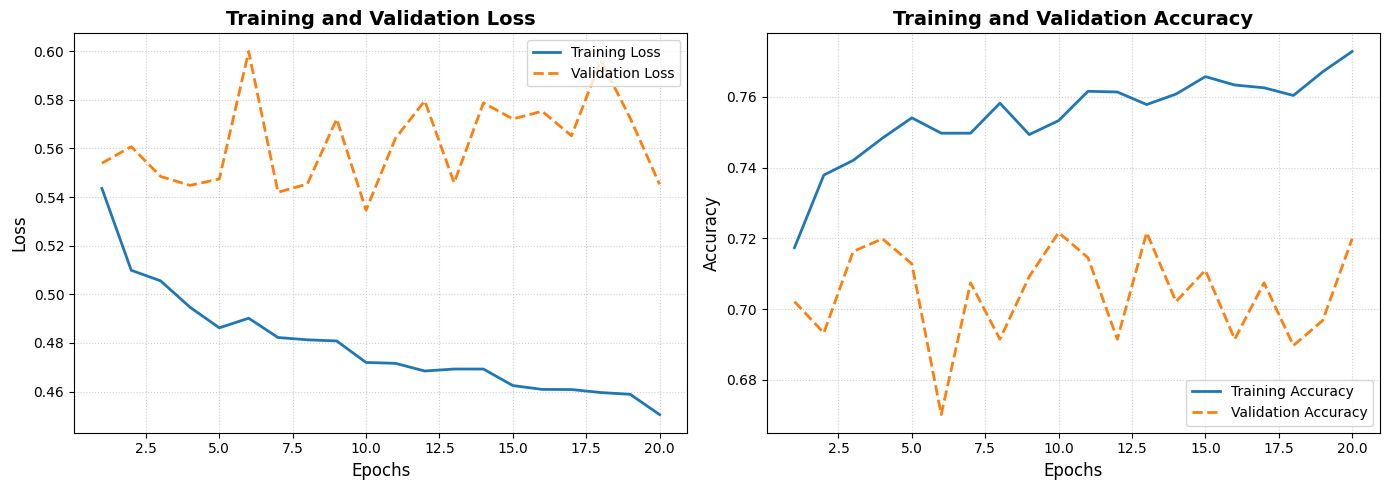

In [124]:
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Plot Training & Validation Loss and Accuracy
# -------------------------------------------------------------------
# Extract history dictionary
acc = model3_history.history['accuracy']
val_acc = model3_history.history['val_accuracy']
loss = model3_history.history['loss']
val_loss = model3_history.history['val_loss']

epochs_range = range(1, len(loss) + 1)

# Create a figure with two subplots side-by-side
plt.figure(figsize=(14, 5))

# Subplot 1: Loss vs Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Accuracy vs Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# Display the plots
plt.tight_layout()
plt.show()

In [126]:
model3.save(
"./models/churn_model.keras"
)

In [127]:
churn_model = keras.models.load_model(
"./models/churn_model.keras"
)

In [142]:
prediction=churn_model.predict(X_test.iloc[[12]])
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
[[0.35267046]]


In [141]:
print(y_test.iloc[[12]])

667    0.0
Name: Churn, dtype: float32
